#### Statistics and Final Figures

In [1]:
import scipy
import statsmodels

print("SciPy version:", scipy.__version__)
print("Statsmodels version:", statsmodels.__version__)

SciPy version: 1.15.3
Statsmodels version: 0.14.6


In [2]:
from pathlib import Path

import pandas as pd
import numpy as np

from scipy.stats import (
    wilcoxon
)

from statsmodels.stats.contingency_tables import (
    mcnemar
)


PROJECT_ROOT = Path("..").resolve()

FINAL_FOLDER = (
    PROJECT_ROOT
    / "Results"
    / "Final"
)


quality = pd.read_csv(
    FINAL_FOLDER
    / "final_query_level_evaluation.csv"
)

Paird Wilcoxon Helper

In [3]:
def paired_wilcoxon(
    dataframe,
    metric,
    system_a,
    system_b
):

    a = (
        dataframe[
            dataframe[
                "system"
            ]
            == system_a
        ][
            [
                "test_id",
                metric
            ]
        ]
        .rename(
            columns={
                metric:
                    "a"
            }
        )
    )


    b = (
        dataframe[
            dataframe[
                "system"
            ]
            == system_b
        ][
            [
                "test_id",
                metric
            ]
        ]
        .rename(
            columns={
                metric:
                    "b"
            }
        )
    )


    paired = a.merge(
        b,
        on="test_id"
    ).dropna()


    if len(paired) == 0:

        return None


    statistic, p_value = (
        wilcoxon(
            paired["a"],
            paired["b"]
        )
    )


    return {
        "metric":
            metric,

        "system_a":
            system_a,

        "system_b":
            system_b,

        "n":
            len(paired),

        "statistic":
            statistic,

        "p_value":
            p_value
    }

In [4]:
tests = []


comparisons = [

    (
        "Single Agent",
        "Coordinated Multi-Agent"
    ),

    (
        "Multi-Agent Without Coordination",
        "Coordinated Multi-Agent"
    )
]


for system_a, system_b in comparisons:

    for metric in [
        "feature_match_ratio",
        "total_latency",
        "total_tokens"
    ]:

        result = paired_wilcoxon(
            quality,
            metric,
            system_a,
            system_b
        )

        if result:

            tests.append(
                result
            )


statistical_results = pd.DataFrame(
    tests
)


display(
    statistical_results
)

,metric,system_a,system_b,n,statistic,p_value
0,feature_match_ratio,Single Agent,Coordinated Multi-Agent,40,0.0,1.024704e-01
1,total_latency,Single Agent,Coordinated Multi-Agent,60,592.0,1.741637e-02
2,total_tokens,Single Agent,Coordinated Multi-Agent,60,14.0,3.293684e-11
3,feature_match_ratio,Multi-Agent Without Coordination,Coordinated Multi-Agent,43,0.0,5.878172e-02
4,total_latency,Multi-Agent Without Coordination,Coordinated Multi-Agent,60,456.0,7.275642e-04
5,total_tokens,Multi-Agent Without Coordination,Coordinated Multi-Agent,60,543.5,8.282075e-01


Paired Cohen's d

In [5]:
def paired_cohens_d(
    dataframe,
    metric,
    system_a,
    system_b
):

    a = (
        dataframe[
            dataframe["system"]
            == system_a
        ][
            [
                "test_id",
                metric
            ]
        ]
        .rename(
            columns={
                metric: "a"
            }
        )
    )


    b = (
        dataframe[
            dataframe["system"]
            == system_b
        ][
            [
                "test_id",
                metric
            ]
        ]
        .rename(
            columns={
                metric: "b"
            }
        )
    )


    paired = a.merge(
        b,
        on="test_id"
    ).dropna()


    differences = (
        paired["a"]
        - paired["b"]
    )


    if (
        len(differences) < 2
        or differences.std(
            ddof=1
        ) == 0
    ):
        return np.nan


    return (
        differences.mean()
        / differences.std(
            ddof=1
        )
    )

Final Graph

In [6]:
import matplotlib.pyplot as plt


final_summary = pd.read_csv(
    FINAL_FOLDER
    / "FINAL_SYSTEM_SUMMARY.csv"
)

feature satisfaction

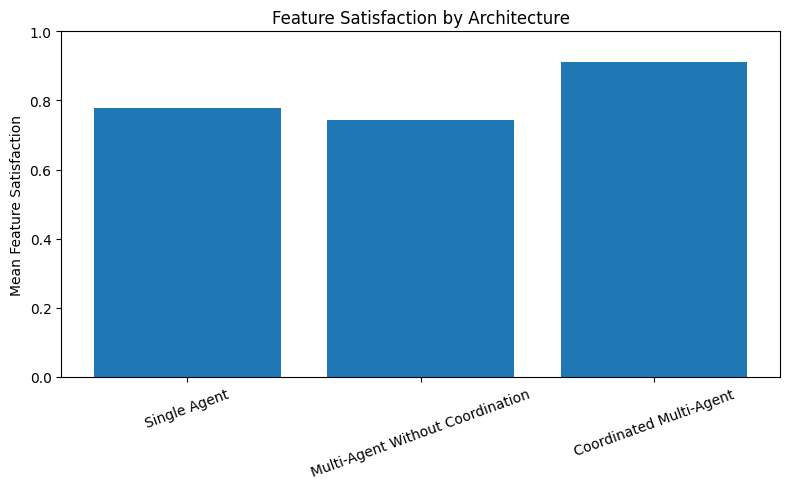

In [7]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    final_summary[
        "system"
    ],
    final_summary[
        "mean_feature_satisfaction"
    ]
)

plt.ylabel(
    "Mean Feature Satisfaction"
)

plt.title(
    "Feature Satisfaction by Architecture"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    FINAL_FOLDER
    / "feature_satisfaction.png",
    dpi=300
)

plt.show()

Grounding

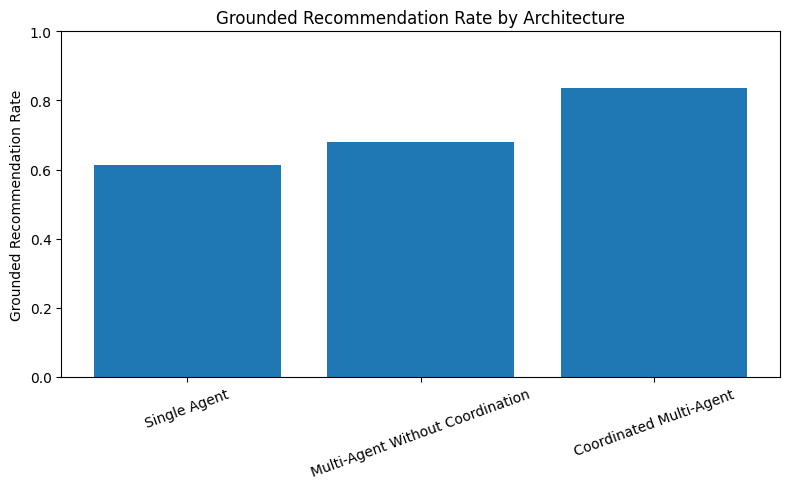

In [8]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    final_summary[
        "system"
    ],
    final_summary[
        "grounded_recommendation_rate"
    ]
)

plt.ylabel(
    "Grounded Recommendation Rate"
)

plt.title(
    "Grounded Recommendation Rate by Architecture"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    FINAL_FOLDER
    / "grounded_recommendations.png",
    dpi=300
)

plt.show()

Hallucination

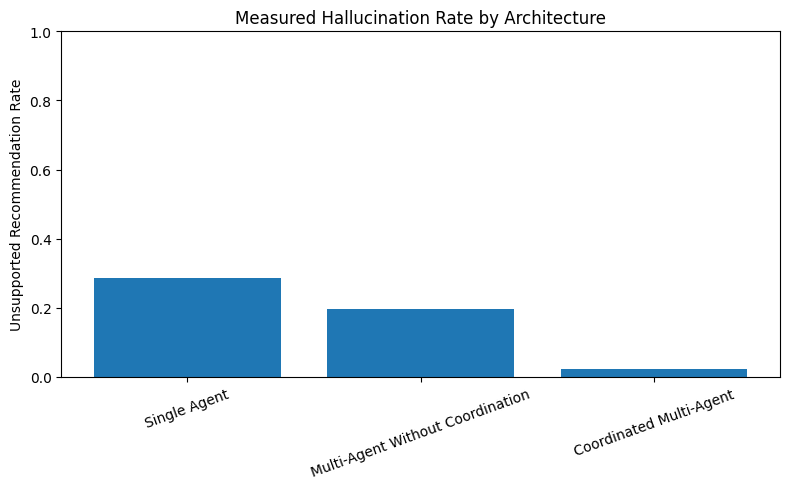

In [9]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    final_summary[
        "system"
    ],
    final_summary[
        "hallucination_rate"
    ]
)

plt.ylabel(
    "Unsupported Recommendation Rate"
)

plt.title(
    "Measured Hallucination Rate by Architecture"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    FINAL_FOLDER
    / "hallucination_rate.png",
    dpi=300
)

plt.show()

Tokens

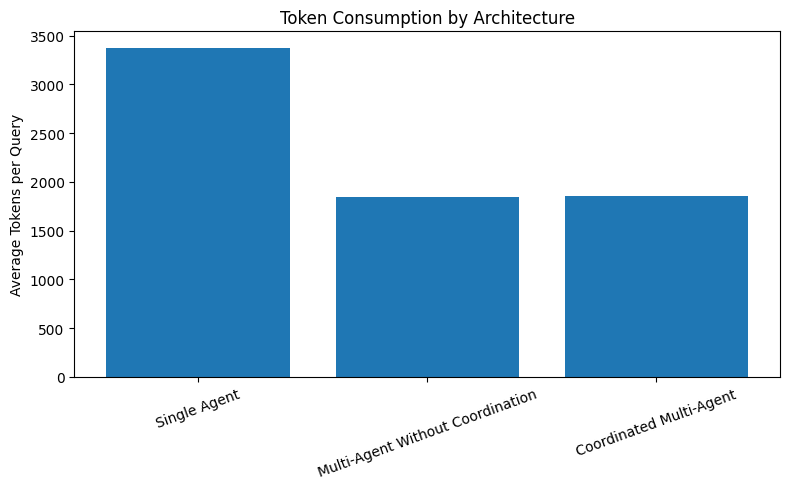

In [10]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    final_summary[
        "system"
    ],
    final_summary[
        "mean_tokens"
    ]
)

plt.ylabel(
    "Average Tokens per Query"
)

plt.title(
    "Token Consumption by Architecture"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    FINAL_FOLDER
    / "token_consumption.png",
    dpi=300
)

plt.show()

Latency

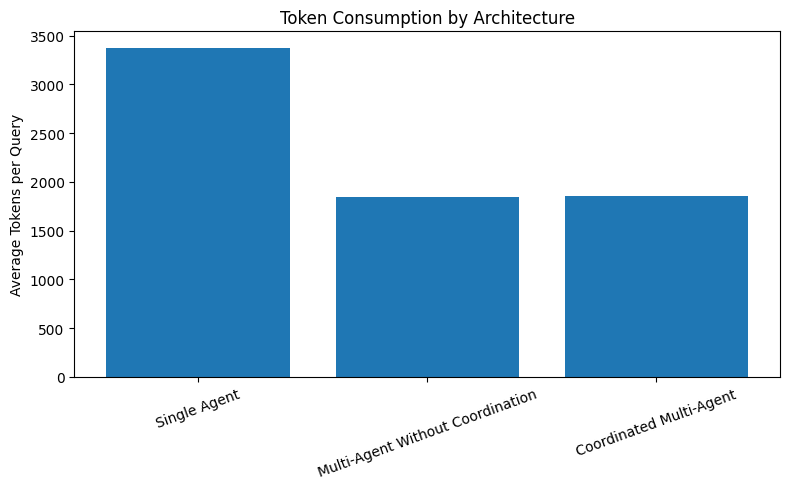

In [11]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    final_summary[
        "system"
    ],
    final_summary[
        "mean_tokens"
    ]
)

plt.ylabel(
    "Average Tokens per Query"
)

plt.title(
    "Token Consumption by Architecture"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    FINAL_FOLDER
    / "token_consumption.png",
    dpi=300
)

plt.show()

#### SAVE STATS

In [12]:
statistical_results.to_csv(
    FINAL_FOLDER
    / "final_statistical_tests.csv",
    index=False
)